# ðŸ“– Tutorial: Training a Disordered FNQS with NetKet Pro

Ce notebook explique comment dÃ©finir, optimiser et Ã©valuer un Ã©tat quantique neuronal fondationnel (FNQS) soumis Ã  un dÃ©sordre structurel (ici un champ magnÃ©tique alÃ©atoire) Ã  l'aide de `netket_foundational` (nkf).

## 1. Theoretical Background

Nous Ã©tudions le modÃ¨le d'Ising 1D en champ transverse avec dÃ©sordre. L'Hamiltonien paramÃ©trÃ© pour une taille de systÃ¨me $L$ est dÃ©fini par :

$$\mathcal{H}(\{h_i\}) = - \sum_{i=1}^{L} h_i \sigma_i^x - J \sum_{i=1}^{L} \sigma_i^z \sigma_{i+1}^z$$

oÃ¹ $J$ est l'interaction d'Ã©change et $h_i$ reprÃ©sente le champ magnÃ©tique local. Le dÃ©sordre est introduit en tirant les $h_i$ d'une distribution statistique (par exemple gaussienne autour d'une moyenne $h_0$).

Pour Ã©valuer la prÃ©cision de l'Ansatz (ViTFNQS), nous utilisons deux mÃ©triques :
* **V-score** : Quantifie la prÃ©cision de l'Ã©nergie variationnelle. $V = \frac{\text{Var}(\mathcal{H})}{\langle \mathcal{H} \rangle^2}$. Une valeur tendant vers 0 indique un Ã©tat propre exact.
* **$\hat{R}$ (R-hat)** : La statistique de Gelman-Rubin. Elle vÃ©rifie la convergence des chaÃ®nes de Markov du sampler de Monte Carlo. Un $\hat{R} \approx 1$ (gÃ©nÃ©ralement $< 1.01$) garantit que l'Ã©chantillonnage est reprÃ©sentatif de la distribution de probabilitÃ© $|\psi(x)|^2$.

## 2. Configuration & Imports

exposer la théorie
faire le calcul exact pour les petites tailles 
début : juste train + plot énergie, Vscore, MZ 
ensuite:
    bloc de tests
    Rhat : montre la qualité de convergence des MCMC
    problème en h0=0
    termaliser les chaînes 
    dérivée de MZ (à voir)
    entrainement par epoch (plutôt non)
    comment enregistrer les données des trains et les récupérer les plots 
    adaptation en 2D
    global flip
    paralel tempering 

In [1]:
import os
os.environ["NETKET_EXPERIMENTAL_SHARDING"] = "1"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import netket as nk
import netket_foundational as nkf
import jax
import jax.numpy as jnp
import numpy as np
from tqdm import tqdm
import optax
import matplotlib.pyplot as plt
from netket_foundational._src.model.vit import ViTFNQS

/users/eleves-a/2024/nikola.audit/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: If timeit=True signals high \% spent sampling n_discarded, consider lowering it.

## 3. System Definition and Disorder Realizations

Nous dÃ©finissons l'espace de Hilbert et gÃ©nÃ©rons un batch de champs magnÃ©tiques dÃ©sordonnÃ©s. L'approche FNQS permet d'optimiser en parallÃ¨le toutes ces rÃ©alisations (rÃ©plicas).

In [2]:
L = 4 #taille du système
J_val = 1.0 #paramètre du hamiltonien 
h0_list = [0.5, 1.0, 1.5] #valeurs moyennes de h sur lequel le NQS sera entrainé
sigma = 0.1 #variance associé au désordre gaussien 
n_replicas = 10 #10 tirages du désordre par valeur de h0_list

#construction de l'espace
hi = nk.hilbert.Spin(0.5, L)
ps = nkf.ParameterSpace(N=hi.size, min=0, max=10*max(h0_list))

#création des différentes réalisations du désordre
def generate_multi_h0_disorder(h0_list, n_reps, system_size, sigma, rng=np.random.default_rng(1)):
    all_configs = []
    for h_m in h0_list:
        raw_configs = rng.normal(loc=h_m, scale=sigma, size=(n_reps, system_size))
        random_configs = np.abs(raw_configs)
        all_configs.append(random_configs)
    return np.vstack(all_configs)

params_list = generate_multi_h0_disorder(h0_list, n_replicas, hi.size, sigma)
total_configs = params_list.shape[0] #nombre total de réalisation du désordre 

## 4. The ViTFNQS Ansatz

Nous utilisons un Vision Transformer adaptÃ© aux Ã©tats quantiques.
Puisque le modÃ¨le n'est pas invariant par translation (Ã  cause du dÃ©sordre local $h_i$), nous configurons l'Ansatz avec `disorder=True` et `transl_invariant=False`.

In [3]:
ma = ViTFNQS(
    num_layers=2,
    d_model=16,
    heads=4, #nombre de têtes d'attention
    b=1, #tailel des patch, ici chaque spin est traité individuellement 
    L_eff=L, 
    n_coups=ps.size, 
    complex=True, #autorise des coeficients complexes
    disorder=True, #désordre local
    transl_invariant=False, #car le système n'est pas invariant par translation
    two_dimensional=False, #passer à True pour un système 2D
)

## 5. Variational Monte Carlo Setup

La parallÃ©lisation sur plusieurs configurations matÃ©rielles est gÃ©rÃ©e par `n_replicas` au sein du `FoundationalQuantumState`. L'Hamiltonien est dit "paramétrisé" car il dépend des valeurs des champs magnétiques transverses appliqués à chaque site. La différence avec une méthode non foundational est que pour le foundational les champs magnétiques seront des paramètres de l'ansatz.

In [4]:
sa = nk.sampler.MetropolisLocal(hi, n_chains=total_configs * 4) #algorityhme de Metropolis-Hastings classique, flip d'un seul spin par étape, 4 chaînes en parallèle par réalisation du désordre

vs = nkf.FoundationalQuantumState(
    sa, ma, ps, #sampler, modèle, espace des parmètres 
    n_replicas=total_configs, 
    n_samples=total_configs * 4 * 16, #16 pas dans chaque chaîne de Markov
    seed=1
)
vs.parameter_array = params_list

#création du hamiltonien à partir d'une réalisation du désordre
def create_operator(params):
    ha_X = sum(params[i] * nkf.operator.sigmax(hi, i) for i in range(hi.size))
    ha_ZZ = sum(nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % hi.size) for i in range(hi.size))
    return -ha_X - J_val * ha_ZZ

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator) #on créer un objet unique qui permet d'accéder à tous les hamiltoniens

/users/eleves-a/2024/nikola.audit/NeuralNetworkQuantumStates/netket_pro/experiments/netket_foundational/_src/vqs/state.py:335: FutureWarning: Call to deprecated function 'check_chunk_size' (This function has been removed. People should be free to use the chunk size they prefer.)
  check_chunk_size(n_samples, self.chunk_size)


## 6. Optimization

EntraÃ®nement simultanÃ© de toutes les rÃ©plicas via descente de gradient stochastique (VMC).

In [ ]:
lr_schedule = optax.linear_schedule(init_value=0.03, end_value=0.005, transition_steps=300)
#pour faire varier le learning rate au cours de l'optimisation
optimizer = optax.sgd(lr_schedule)

def cg_solver(A, b):
    return jax.scipy.sparse.linalg.cg(A, b, tol=1e-4)[0]

gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=2e-4, linear_solver_fn=cg_solver)

log = nk.logging.RuntimeLog()

gs.run(n_iter=150, out=log, obs={"ham": ha_p})

100%|██████████| 150/150 [06:03<00:00,  2.42s/it, Energy=-5.41+0.00j ± 0.18 [σ²=1.1e+00]]


(RuntimeLog():
  keys = ['Energy', 'acceptance', 'ham'],)

In [21]:
print(f"Nombre de configurations (répliques) : {len(log.data['ham'][0].Mean)}")
print(f"Nombre d'itérations enregistrées : {len(log.data['ham'])}")
print(log.data['ham'])

Nombre de configurations (répliques) : 150
Nombre d'itérations enregistrées : 30
[History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   iters = [0, 1, ... 148, 149] (150 steps),
), History(
   keys  = ['Mean', 'Variance', 'Sigma', 'R_hat', 'TauCorr'], 
   ite

<>:35: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1315372/1570106799.py:35: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("Énergie $\langle H \\rangle$", fontsize=12)


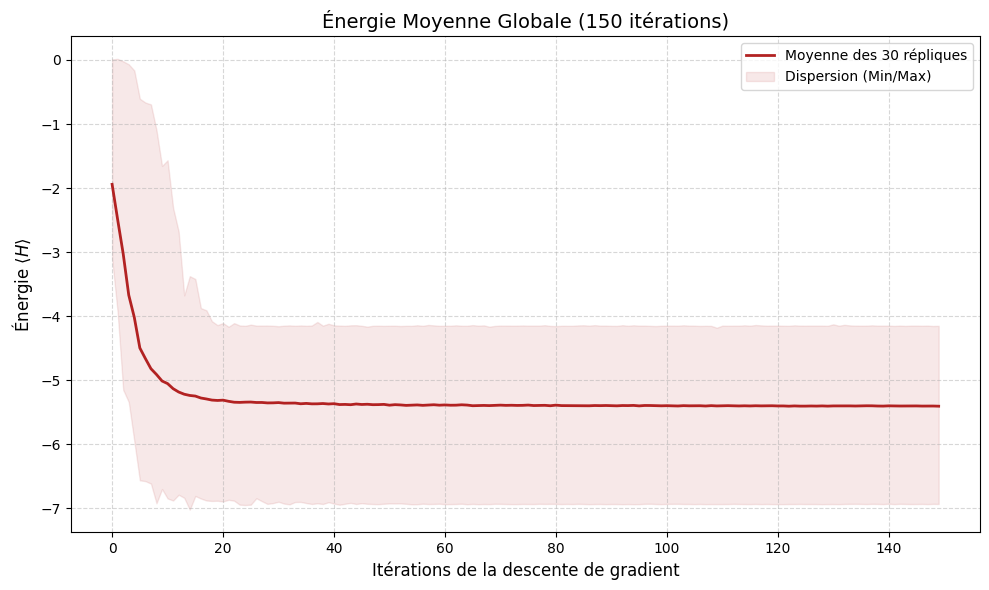

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 1. On récupère la liste des 30 objets History
h_list = log.data["ham"] 

# 2. On construit une matrice (Nombre de Répliques, Nombre d'Itérations)
# On extrait le champ .Mean.real de chaque réplique
# Cela nous donne une matrice de forme (30, 150)
energy_matrix = np.array([h.Mean.real for h in h_list])

# 3. On calcule la moyenne sur les 30 répliques (axe 0)
# On obtient un vecteur de 150 points
mean_energy_over_time = np.mean(energy_matrix, axis=0)

# 4. On récupère les itérations (0 à 149) depuis le premier objet
iterations = h_list[0].iters

# --- PLOT SIMPLE ---
plt.figure(figsize=(10, 6))

# Courbe de l'énergie moyenne
plt.plot(iterations, mean_energy_over_time, 
         color='firebrick', linewidth=2, label="Moyenne des 30 répliques")

# Optionnel : Zone d'ombre pour voir l'écart entre la réplique 
# la plus basse et la plus haute (le désordre)
plt.fill_between(iterations, 
                 np.min(energy_matrix, axis=0), 
                 np.max(energy_matrix, axis=0), 
                 color='firebrick', alpha=0.1, label="Dispersion (Min/Max)")

plt.title("Énergie Moyenne Globale (150 itérations)", fontsize=14)
plt.xlabel("Itérations de la descente de gradient", fontsize=12)
plt.ylabel("Énergie $\langle H \\rangle$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

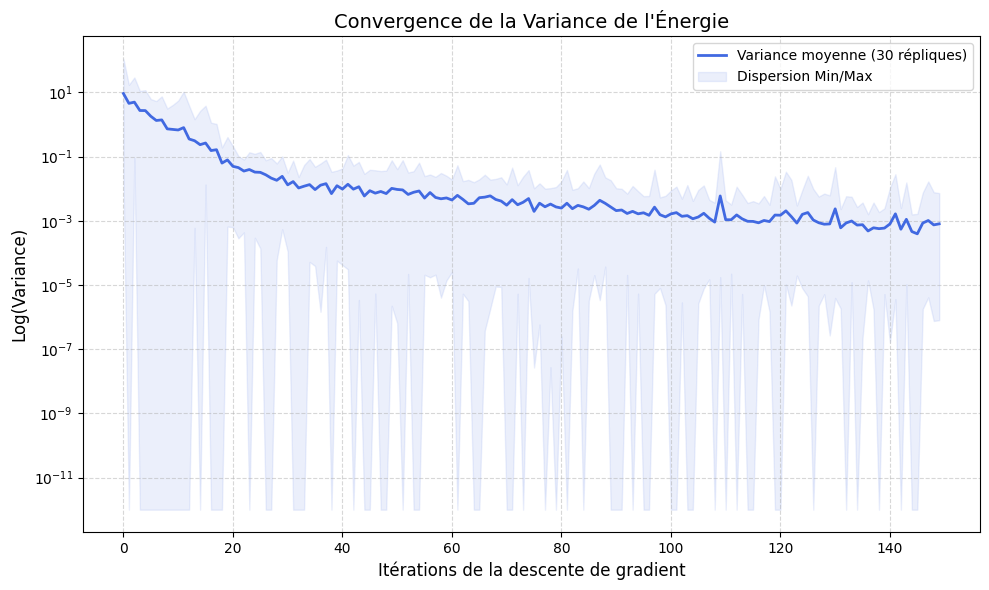

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraction de la liste des 30 historiques
h_list = log.data["ham"]

# 2. Construction de la matrice des variances (30 répliques x 150 itérations)
# On utilise .Variance (majuscule) comme indiqué dans votre dump de logger
var_matrix = np.array([h.Variance for h in h_list])

# 3. Calcul de la moyenne des variances sur les 30 répliques
mean_var_over_time = np.mean(var_matrix, axis=0)
iterations = h_list[0].iters

# --- PLOT DE LA VARIANCE ---
plt.figure(figsize=(10, 6))

# Tracé en échelle logarithmique pour mieux voir la convergence
plt.semilogy(iterations, mean_var_over_time, 
             color='royalblue', linewidth=2, label="Variance moyenne (30 répliques)")

# Optionnel : Zone d'ombre pour la dispersion du désordre
plt.fill_between(iterations, 
                 np.min(var_matrix, axis=0) + 1e-12, # +1e-12 pour éviter log(0)
                 np.max(var_matrix, axis=0) + 1e-12, 
                 color='royalblue', alpha=0.1, label="Dispersion Min/Max")

plt.title("Convergence de la Variance de l'Énergie", fontsize=14)
plt.xlabel("Itérations de la descente de gradient", fontsize=12)
plt.ylabel("Log(Variance)", fontsize=12)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

## 7. Diagnostics : V-Score & $\hat{R}$

Nous Ã©valuons la prÃ©cision (V-score) et la qualitÃ© d'Ã©chantillonnage ($\hat{R}$) du modÃ¨le entraÃ®nÃ© pour chaque rÃ©alisation du dÃ©sordre.

In [ ]:
v_scores = []
r_hats = []

print("Ã‰valuation des mÃ©triques finales...")
for r in range(total_configs):
    pars = params_list[r]
    _vs = vs.get_state(pars)
    
    vs_mc = nk.vqs.MCState(
        sampler=nk.sampler.MetropolisLocal(hi, n_chains=16), 
        model=_vs.model, 
        variables=_vs.variables, 
        n_samples=2048
    )
    
    _ha = create_operator(pars)
    stats = vs_mc.expect(_ha)
    
    val = stats.variance / (stats.Mean.real**2 + 1e-12)
    v_scores.append(val)
    
    r_hats.append(stats.R_hat)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(v_scores, bins=10, color='blue', alpha=0.7)
plt.title("Distribution des V-scores")
plt.xlabel("V-score")

plt.subplot(1, 2, 2)
plt.hist(r_hats, bins=10, color='green', alpha=0.7)
plt.axvline(1.01, color='red', linestyle='dashed', label='Limite typique de convergence')
plt.title("Distribution de R-hat ($\hat{R}$)")
plt.xlabel("$\hat{R}$")
plt.legend()
plt.show()